In [595]:
from pathlib import Path

import numpy as np
import pypulseq as pp
from bmc.utils.seq.write import write_seq

import matplotlib.pyplot as plt

In [596]:
wdir = Path().resolve().parent
folder = wdir / "seq_lib"

sys = pp.Opts(
    max_grad=12000,
    grad_unit="mT/m",
    max_slew=1e9,
    slew_unit="T/m/s",
    rf_ringdown_time=0,
    rf_dead_time=0,
    rf_raster_time=1e-6,
    gamma=42576400,
    grad_raster_time=1e-6,
)
# general settings
AUTHOR = "DANIEL MIKSCH"
FLAG_PLOT_SEQUENCE = True  # plot preparation block?
FLAG_CHECK_TIMING = True  # perform a timing check at the end of the sequence?
FLAG_POST_PREP_SPOIL = True  # add spoiler after preparation block?

defs: dict = {}

### Definitions

In [597]:
seqid = "custom_ETM" #file name

defs["a"] = 90 # alpha in degrees
defs["b0"] = 17  # B0 [T]
defs["m0_offset"] = 8  # m0 offset [ppm]
defs["n_ETM"] = 1  # number of ETMs

#rf settings
flip_angle_90 = np.radians(defs['a'])
flip_angle_180 = np.radians(180)
t_pulse = 2e-3 

#gradient settings
spoil_amp = 0.109 * sys.max_grad  # Hz/m
# spoil_amp = 0.108 * sys.max_grad  # Hz/m
# spoil_amp = 0.15 * sys.max_grad  # Hz/m

crush_amp = 0.218 * sys.max_grad  # Hz/m
# crush_amp = 0.05 * sys.max_grad  # Hz/m

rise_time = 0.05e-3 #(spoil_amp / GAMMA_HZ) / sys.max_slew  # spoiler rise time in seconds
spoil_dur = 0.5e-3  # complete spoiler duration in seconds
exchange_dur = 80e-3
rephase_dur = 2e-3

#delay settings
delay_inter_etm = pp.make_delay(0.5e-3)
delay_exchange = pp.make_delay(80e-3)

pseudo_delay = pp.make_delay(1e-3)

#adc
pseudo_adc = pp.make_adc(num_samples=1, duration=1e-3)


In [598]:
defs["offsets_ppm"] = np.array([defs["m0_offset"]])
defs["num_meas"] = defs["offsets_ppm"].size  # number of repetition
defs["seq_id_string"] = seqid  # unique seq id
seq_filename = defs["seq_id_string"] + ".seq"
GAMMA_HZ = sys.gamma * 1e-6
defs["freq"] = defs["b0"] * GAMMA_HZ  # Larmor frequency [Hz]

### RF events

In [599]:
rf_90 = pp.make_gauss_pulse(
    flip_angle=flip_angle_90,
    system=sys,
    duration=t_pulse,         # Bandbreite in Hz
    center_pos=0.5,
    freq_offset=0,
    phase_offset=0,
    return_gz=False)

rf_90_re = pp.make_gauss_pulse(
    flip_angle=flip_angle_90,
    system=sys,
    duration=t_pulse,         # Bandbreite in Hz
    center_pos=0.5,
    freq_offset=0,
    phase_offset=np.radians(180),
    return_gz=False)

rf_90_water = pp.make_gauss_pulse(
    flip_angle=np.radians(90),
    system=sys,
    duration=t_pulse,         # Bandbreite in Hz
    center_pos=0.5,
    freq_offset=0,
    phase_offset=0,
    return_gz=False)

rf_180 = pp.make_gauss_pulse(
    flip_angle=flip_angle_180,
    system=sys,
    duration=t_pulse,
    center_pos=0.5,
    freq_offset=0,
    phase_offset=0,
    return_gz=False)

### Gradient events

In [600]:
# def create_trapezoid(amplitude, duration, rise_time, dt=sys.grad_raster_time):
#     if 2 * rise_time > duration:
#         raise ValueError("Die Anstiegs- und Abfallzeit zusammen dürfen nicht länger als die Gesamtdauer sein.")

#     # Anzahl der Samples für jede Phase
#     num_rise_samples = int(rise_time / dt)  # Anzahl der Samples für die Anstiegsphase
#     num_flat_samples = int((duration - 2 * rise_time) / dt)  # Anzahl der Samples für das Plateau
#     total_samples = num_rise_samples * 2 + num_flat_samples  # Gesamte Anzahl der Samples

#     # Trapezoid erstellen
#     trapezoid = np.zeros(total_samples)

#     # Anstiegsphase: Linear von 0 bis zur Amplitude
#     rise = np.linspace(0, amplitude, num_rise_samples, endpoint=False)
#     trapezoid[:num_rise_samples] = rise

#     # Plateau: Konstante Amplitude
#     trapezoid[num_rise_samples:num_rise_samples + num_flat_samples] = amplitude

#     # Abfallphase: Linear von Amplitude zurück auf 0
#     fall = np.linspace(amplitude, 0, num_rise_samples, endpoint=True)
#     trapezoid[num_rise_samples + num_flat_samples:] = fall

#     return trapezoid

In [601]:
def create_trapezoid(amplitude, duration, rise_time, total_length, dt=sys.grad_raster_time):
    """
    Erzeugt einen trapezförmigen Gradientimpuls, der in ein
    Array der Länge `total_length` (in Sekunden) zentriert wird.
    Alle Werte, die 0 ergeben, werden auf 3 gesetzt.
    
    Parameters:
    -----------
    amplitude : float
        Maximale Amplitude des Impulses.
    duration : float
        Dauer des Impulses (in Sekunden).
    rise_time : float
        Dauer der Anstiegs-/Abfallphase (in Sekunden).
    dt : float
        Zeitauflösung (in Sekunden).
    total_length : float
        Gesamtdauer des Rückgabevektors (in Sekunden).
        
    Returns:
    --------
    numpy.ndarray
        Array der Länge total_length/dt, in dem der Gradientimpuls mittig liegt,
        und alle 0-Werte durch 3 ersetzt wurden.
    """
    import numpy as np

    total_samples = int(round(total_length / dt))
    num_rise_samples = int(rise_time / dt)
    num_flat_samples = int((duration - 2 * rise_time) / dt)
    pulse_samples = num_rise_samples * 2 + num_flat_samples

    if pulse_samples > total_samples:
        raise ValueError("Die Gesamtlänge muss länger als die Pulsdauer sein.")

    # Erstelle den trapezförmigen Impuls
    rise = np.linspace(0, amplitude, num_rise_samples, endpoint=False)
    plateau = amplitude * np.ones(num_flat_samples)
    fall = np.linspace(amplitude, 0, num_rise_samples, endpoint=True)
    pulse = np.concatenate([rise, plateau, fall])

    # Erstelle das Gesamtsignal mit Hintergrundwert 3
    signal = np.full(total_samples, 3)
    start = (total_samples - pulse_samples) // 2
    signal[start:start+pulse_samples] = pulse

    # Ersetze sämtliche Nullen im Signal durch 3
    signal[signal == 0] = 3

    return signal

In [602]:
#!/usr/bin/env python
# filepath: vscode-notebook-cell:/Users/danielmiksch/JupyterLab/optim/seq_init/custom_ETM.ipynb
import math
import numpy as np
from types import SimpleNamespace
from warnings import warn
from copy import copy
from typing import Union

# Angenommen, pypulseq.opts.Opts wird so importiert:
from pypulseq.opts import Opts
from pypulseq.supported_labels_rf_use import get_supported_rf_uses

def __gauss(x: np.ndarray) -> np.ndarray:
    return np.exp(-np.pi * np.square(x))

def make_double_gauss_pulse(
    flip_angle: float,
    apodization: float = 0,
    bandwidth: float = 0,
    center_pos: float = 0.5,
    delay: float = 0,
    dwell: float = 0,
    duration: float = 4e-3,
    gap: float = 1e-3,
    freq_offset: float = 0,
    phase_offset: float = 0,
    time_bw_product: float = 4,
    use: str = "",
    system: Union[Opts, None] = None,
    dead_time: float = 0,
    ringdown_time: float = 0
) -> SimpleNamespace:
    """
    Erzeugt ein Doppelpulspaar aus zwei Gauss-Pulsen à la make_gauss_pulse, wobei zwischen den Pulsen 
    eine Lücke (gap) eingefügt wird, die mit dem letzten Wert des ersten Pulses gefüllt wird.
    
    Die Parameter system, dwell, dead_time und ringdown_time werden analog zur Originalfunktion verwendet.
    
    Returns:
    --------
    rf : SimpleNamespace
        RF-Objekt mit den folgenden Feldern:
         - type: 'rf'
         - signal: Der Amplitudenarray (Doppelpuls mit Gap)
         - t: Zeitvektor passend zur Gesamtdauer des Signals
         - shape_dur: Gesamtdauer (Signaldauer)
         - freq_offset, phase_offset, delay, dead_time, ringdown_time und use (falls gesetzt)
    """
    # System setzen, falls nicht übergeben
    if system is None:
        system = Opts.default

    # Prüfe use, falls gesetzt
    if use != "" and use not in get_supported_rf_uses():
        raise ValueError(f"Invalid use parameter. Must be one of {get_supported_rf_uses()}. Passed: {use}")

    # Falls dwell nicht gesetzt, verwende den system.rf_raster_time
    if dwell == 0:
        dwell = system.rf_raster_time

    # Bandwidth setzen, falls nicht übergeben
    if bandwidth == 0:
        bandwidth = time_bw_product / duration

    # Anzahl Samples für einen einzelnen Gauss-Puls
    n_samples = int(round(duration / dwell))
    t_single = (np.arange(1, n_samples + 1) - 0.5) * dwell
    tt_single = t_single - (duration * center_pos)
    
    # Fensterfunktion
    window = 1 - apodization + apodization * np.cos(2 * np.pi * tt_single / duration)
    signal_single = window * __gauss(bandwidth * tt_single)
    
    # Normierungsfaktor: Fläche unter dem Puls (multipliziert mit 2*pi)
    flip_calc = np.sum(signal_single) * dwell * 2 * np.pi
    signal_single = signal_single * flip_angle / flip_calc

    # Erzeuge das Gap: Berechne Anzahl Samples für gap und fülle es mit dem letzten Wert des ersten Pulses.
    n_gap = int(round(gap / dwell))
    gap_array = np.full(n_gap, signal_single[-1])
    # gap_array = np.full(n_gap, 0)
    
    # Erstelle finalen Amplitudenarray: erster Puls, dann Gap, dann zweiter Puls (gleicher Gauss-Puls)
    double_signal = np.concatenate([signal_single, gap_array, signal_single])
    
    # Erstelle Zeitvektor entsprechend
    t_gap = t_single[-1] + dwell + np.arange(n_gap) * dwell
    t_second = t_single + (t_gap[-1] + dwell)
    t_double = np.concatenate([t_single, t_gap, t_second])
    
    rf = SimpleNamespace()
    rf.type = 'rf'
    rf.signal = double_signal
    rf.t = t_double
    rf.shape_dur = double_signal.size * dwell
    rf.freq_offset = freq_offset
    rf.phase_offset = phase_offset
    rf.delay = delay
    rf.dead_time = dead_time
    rf.ringdown_time = ringdown_time
    if use != "":
        rf.use = use

    if rf.dead_time > rf.delay:
        warn(
            f"Specified RF delay {rf.delay*1e6:.2f} µs is less than the dead time {rf.dead_time*1e6:.0f} µs. "
            f"Delay was increased to the dead time.",
            stacklevel=2
        )
        rf.delay = rf.dead_time

    # Workaround für negative Nullen, analog zum Original:
    negative_zero_indices = np.where(rf.signal == -0.0)
    rf.signal[negative_zero_indices] = 0

    return rf

[]


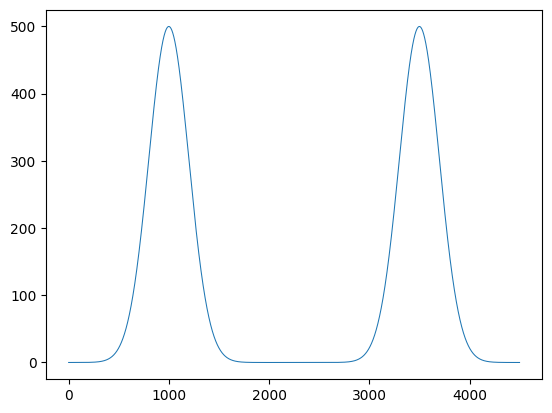

In [603]:
rf_90_double = make_double_gauss_pulse(
    flip_angle=np.radians(90),
    duration=t_pulse,         # Bandbreite in Hz
    center_pos=0.5,
    gap=0.5e-3,
    system=sys,
    freq_offset=0,
    phase_offset=0)

plt.plot(rf_90_double.signal)
len(rf_90_double.signal)
indices = np.where(rf_90_double.signal <= 15e-4)[0]
print(indices)

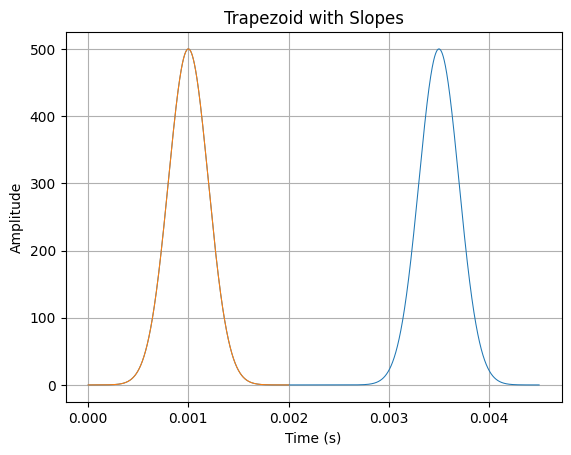

55689931.2

In [604]:
dt = sys.grad_raster_time  # Zeitauflösung

trapezoid = create_trapezoid(spoil_amp, spoil_dur, rise_time, total_length=2.0e-3)

# Plot
import matplotlib.pyplot as plt
# time = np.arange(len(rf_90_double.signal)) * dt  # Zeitachse
# time_rf = np.arange(len(rf_90.signal)) * dt  # Zeitachse
plt.plot(rf_90_double.t, rf_90_double.signal)
plt.plot(rf_90.t, rf_90.signal)
plt.title("Trapezoid with Slopes")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid()
plt.show()
spoil_amp

In [605]:
trapeziod_spoil = create_trapezoid(spoil_amp, spoil_dur, rise_time, total_length=4.5e-3)
trapeziod_rephase = create_trapezoid(spoil_amp, rephase_dur, rise_time, total_length=rephase_dur)
# trapeziod_spoil_minus = create_trapezoid(-spoil_amp, spoil_dur, rise_time)
trapeziod_exchange = create_trapezoid(crush_amp, exchange_dur, rise_time, total_length=exchange_dur)

gz_spoil = pp.make_arbitrary_grad(channel='z', 
                             system=sys, 
                             waveform=trapeziod_spoil,
                             first=0,
                             last=0
                             )
gz_rephase = pp.make_arbitrary_grad(channel='z',
                                    system=sys,
                                    waveform=trapeziod_rephase,
                                    first=0,
                                    last=0
                                    )
gz_exchange = pp.make_arbitrary_grad(channel='z',
                                     system=sys,
                                     waveform=trapeziod_exchange,
                                     first=0,
                                     last=0
                                     )


### Sequence

In [606]:
seq = pp.Sequence()
offsets_hz = defs["offsets_ppm"] * defs["freq"]  # convert from ppm to Hz

In [607]:

rf_90.freq_offset = offsets_hz[0]
rf_90_double.freq_offset = offsets_hz[0]


for i in range(defs["n_ETM"]):
    seq.add_block(pseudo_delay)
    seq.add_block(rf_90_double, gz_spoil)
    # seq.add_block(gz_exchange)
    seq.add_block(delay_exchange)
    
seq.add_block(rf_90_water)
# seq.add_block(delay_inter_etm)
seq.add_block(gz_rephase)
seq.add_block(pseudo_adc)


Timing check passed successfully


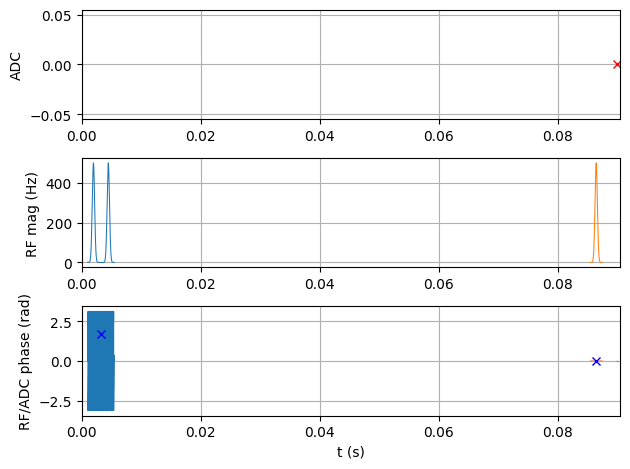

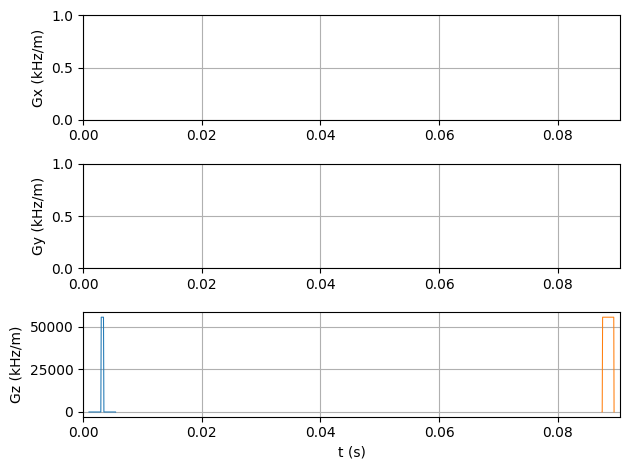

In [608]:
if FLAG_CHECK_TIMING:
    ok, error_report = seq.check_timing()
if ok:
    print("\nTiming check passed successfully")
else:
    print("\nTiming check failed! Error listing follows\n")
    print(error_report)

if FLAG_PLOT_SEQUENCE:
    seq.plot(time_range=[0.00, .1]) #time_range=[0.00, .03]

In [609]:
write_seq(seq=seq, seq_defs=defs, filename=folder / seq_filename, author=AUTHOR, use_matlab_names=True)

In [610]:
test = ((np.arange(500) + 0.5) * 1e-6)
(test[1] - test[0]) * 500

np.float64(0.0005000000000000001)

In [611]:
from bmc.utils.eval import calculate_flip_angle
import torch
pp.calc_rf_bandwidth(rf_90_double)
pp.calc_duration(rf_90_double)
t = rf_90_double.t[1] - rf_90_double.t[0]
calculate_flip_angle(torch.tensor(rf_90_double.signal), t)
# print(rf_90.signal)
# print(rf_90_double.signal)

179.99968217103947

In [612]:
rf_90_double.t

array([5.000e-07, 1.500e-06, 2.500e-06, ..., 4.498e-03, 4.499e-03,
       4.500e-03], shape=(4500,))